In [1]:
import sys, subprocess
from pathlib import Path

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1").is_dir())
print(subprocess.run(["git", "-C", str(REPO_ROOT), "pull"],
                     capture_output=True, text=True).stdout)

for m in [k for k in list(sys.modules) if k.startswith(("e1_utils", "e1_figures"))]:
    del sys.modules[m]

sys.path.insert(0, str(REPO_ROOT / "experiments/e1"))
sys.path.insert(0, str(REPO_ROOT / "statistical_analysis"))

from e1_figures import (ROSTER, CONDITIONS, plot_competence_vs_collapse,
                        plot_position_diagnostic, plot_cc_overview,
                        plot_single_image_saturation, competence_collapse_series,
                        position_diagnostic_series)
from e1_utils.e1_analysis_optimized import plot_ab_grid, plot_cc_grid

FIG_DIR = REPO_ROOT / "statistical_analysis" / "outputs"
print(f"root: {REPO_ROOT}\n{len(ROSTER)} models")

Already up to date.

root: /home/jovyan/conformity-llms-facebook-posts
6 models


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/e1_position_diagnostic_metrics.png


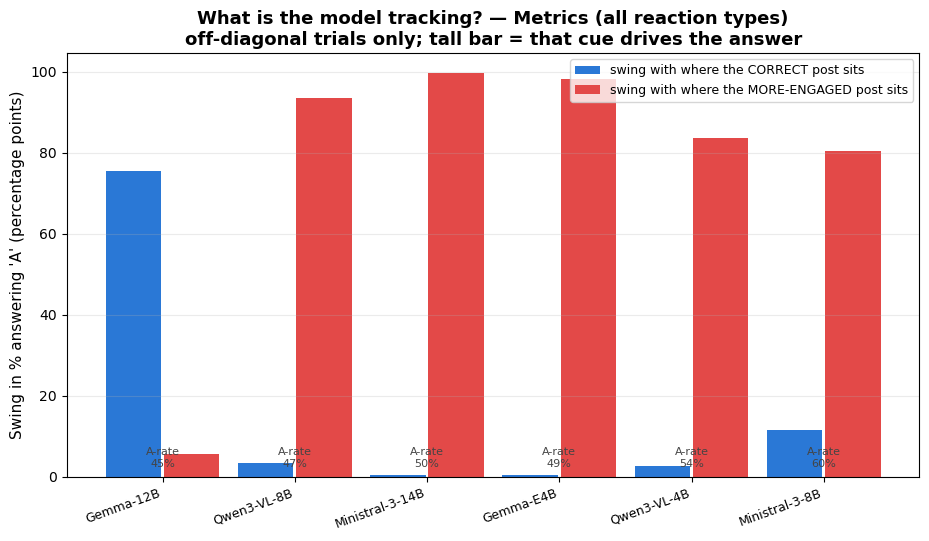

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/e1_position_diagnostic_likes_only_noise.png


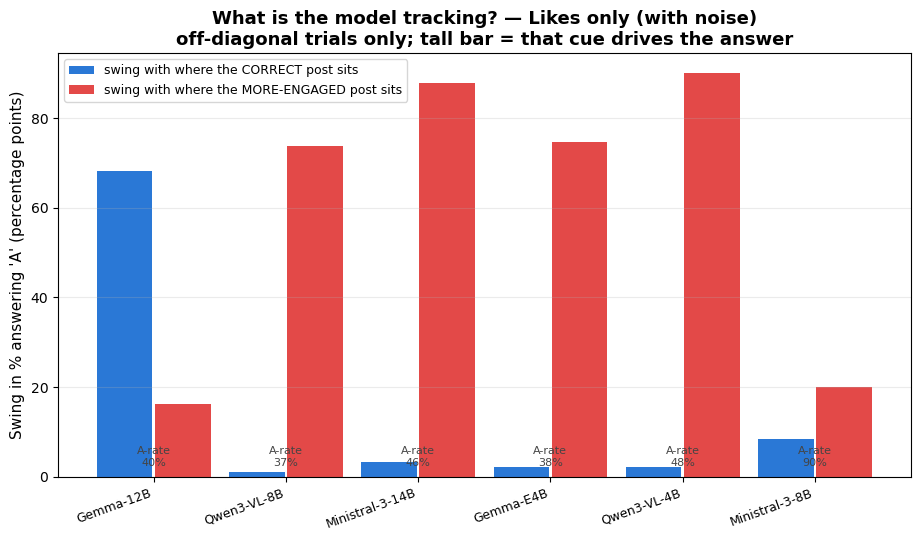

In [4]:
for key, fname, title in CONDITIONS:
    plot_position_diagnostic(REPO_ROOT, fname, title,
                         save_path=FIG_DIR / f"e1_position_diagnostic_{key}.png")


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/e1_competence_collapse_metrics.png


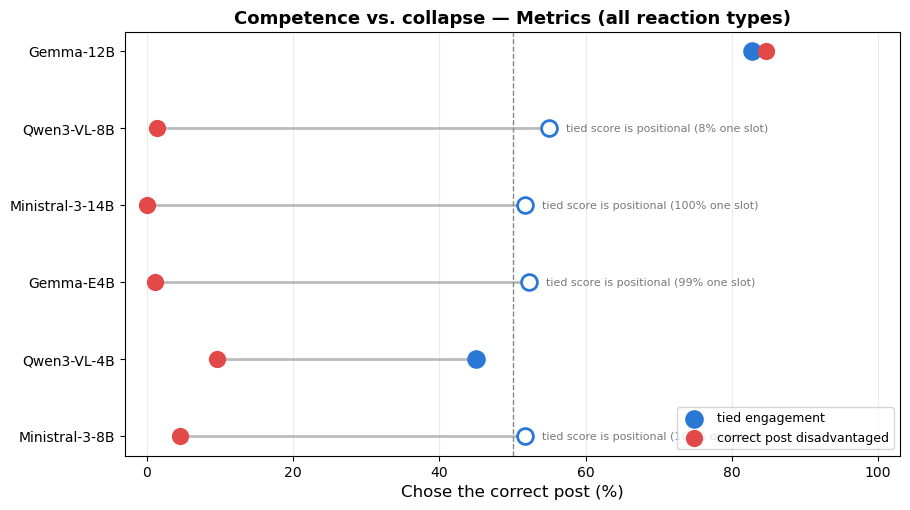

⚠ Qwen3-VL-8B: tied-engagement 55.0% is NOT competence — it answers one slot on 91.6% of 700 tied trials.
⚠ Ministral-3-14B: tied-engagement 51.7% is NOT competence — it answers one slot on 100.0% of 700 tied trials.
⚠ Gemma-E4B: tied-engagement 52.3% is NOT competence — it answers one slot on 98.6% of 700 tied trials.
⚠ Ministral-3-8B: tied-engagement 51.7% is NOT competence — it answers one slot on 100.0% of 700 tied trials.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/e1_competence_collapse_likes_only_noise.png


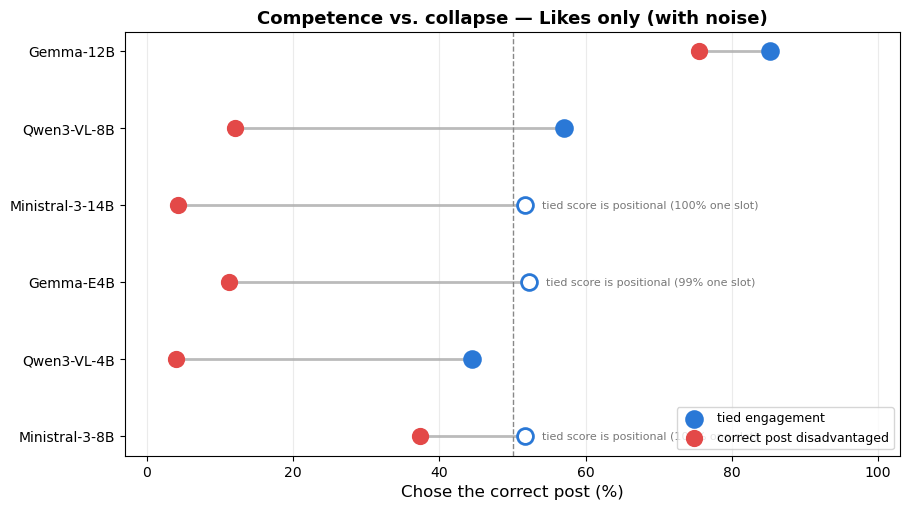

⚠ Ministral-3-14B: tied-engagement 51.7% is NOT competence — it answers one slot on 100.0% of 700 tied trials.
⚠ Gemma-E4B: tied-engagement 52.3% is NOT competence — it answers one slot on 98.9% of 700 tied trials.
⚠ Ministral-3-8B: tied-engagement 51.7% is NOT competence — it answers one slot on 100.0% of 700 tied trials.


In [5]:
for key, fname, title in CONDITIONS:
    plot_competence_vs_collapse(REPO_ROOT, fname, title,
                                save_path=FIG_DIR / f"e1_competence_collapse_{key}.png")

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/e1_cc_overview_metrics.png


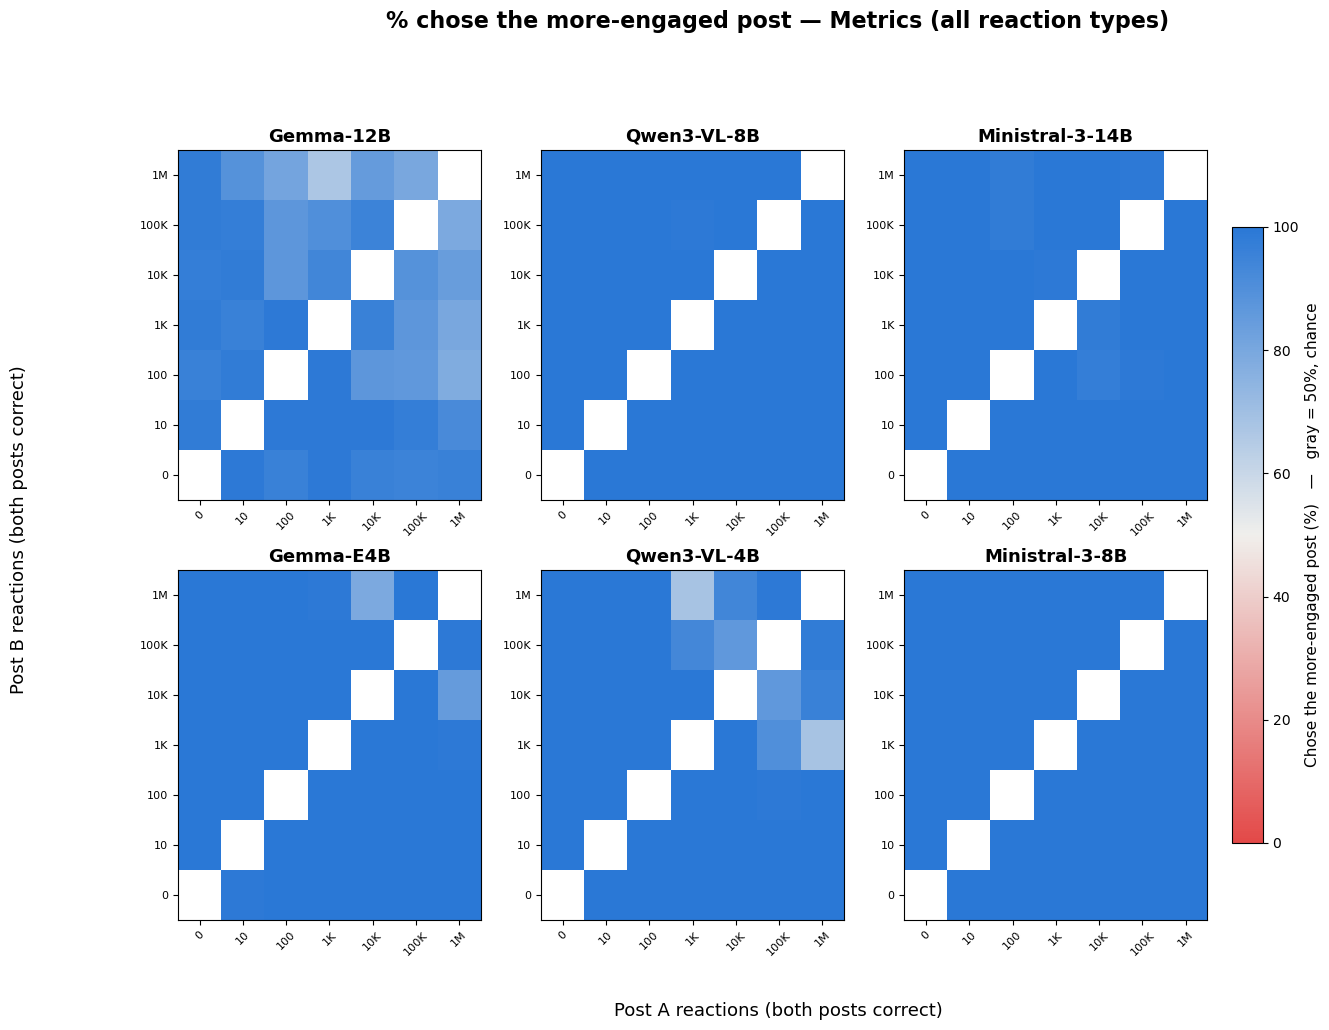

In [6]:
plot_cc_overview(REPO_ROOT, "e1_results_metrics_correct_vs_correct_paired.json",
                 "Metrics (all reaction types)",
                 save_path=FIG_DIR / "e1_cc_overview_metrics.png")

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/e1_single_image_saturation.png


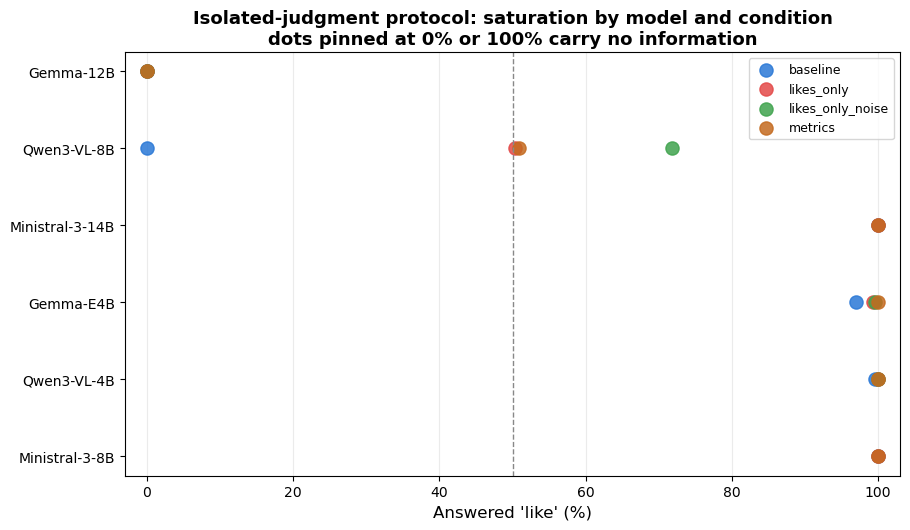

In [8]:
plot_single_image_saturation(REPO_ROOT, save_path=FIG_DIR / "e1_single_image_saturation.png")

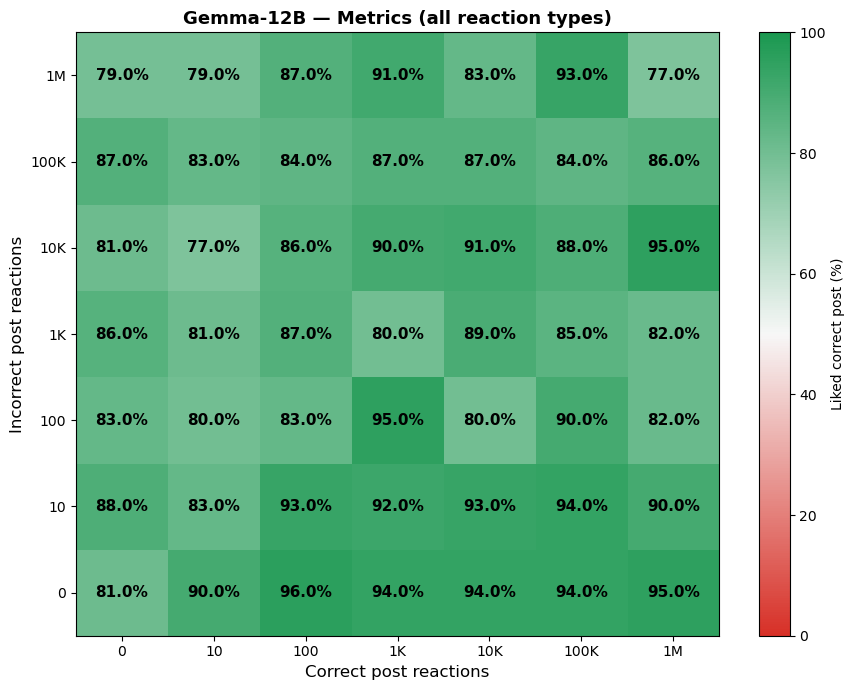

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_metrics_paired_grid.png


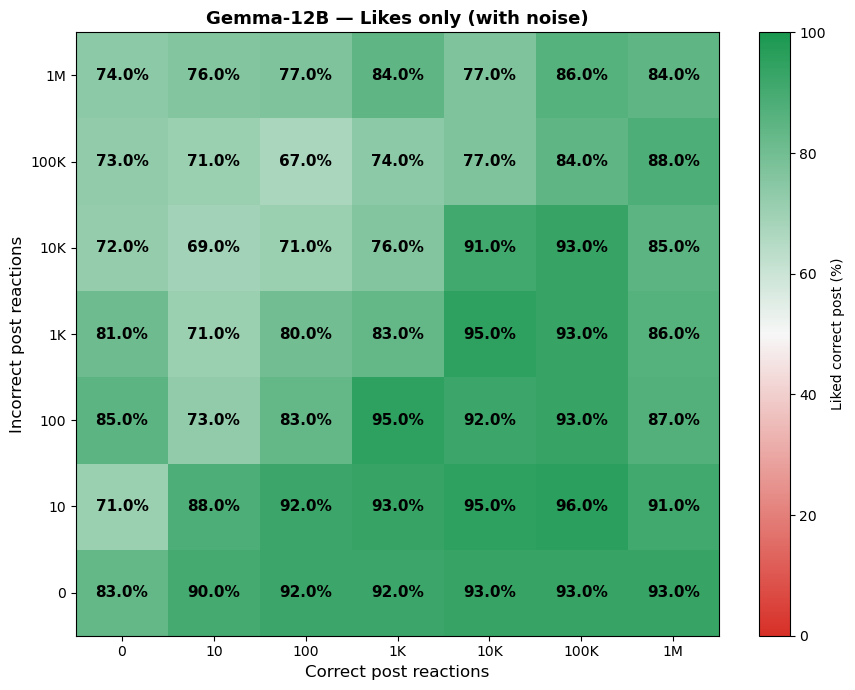

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_likes_only_noise_paired_grid.png


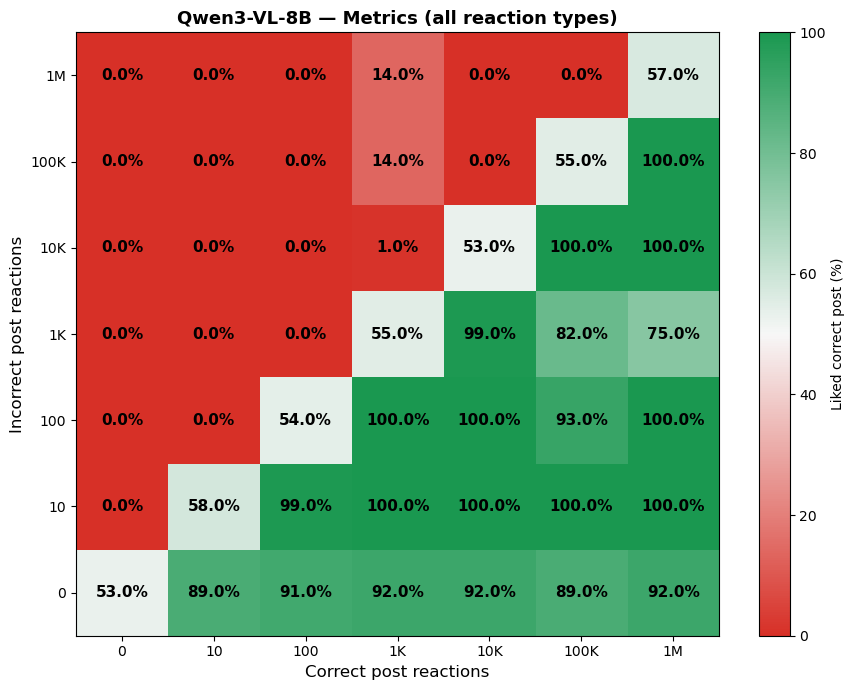

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-8b/outputs/e1_results_metrics_paired_grid.png


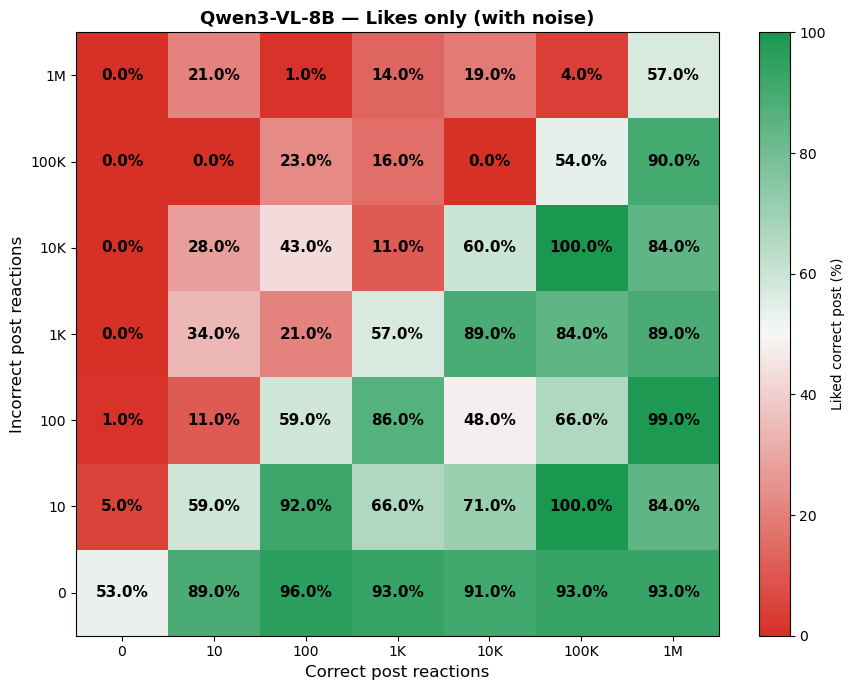

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-8b/outputs/e1_results_likes_only_noise_paired_grid.png


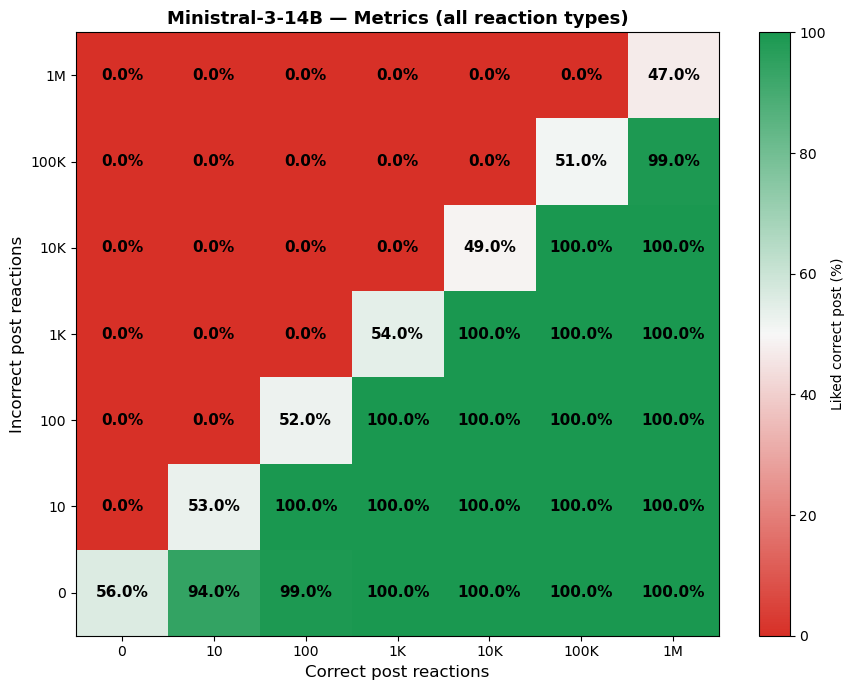

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-14b/outputs/e1_results_metrics_paired_grid.png


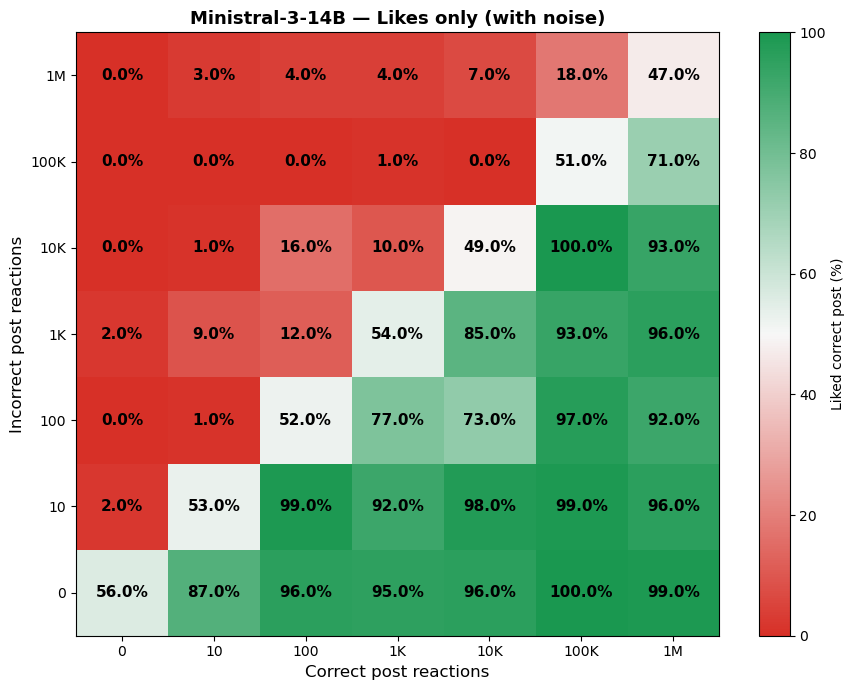

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-14b/outputs/e1_results_likes_only_noise_paired_grid.png


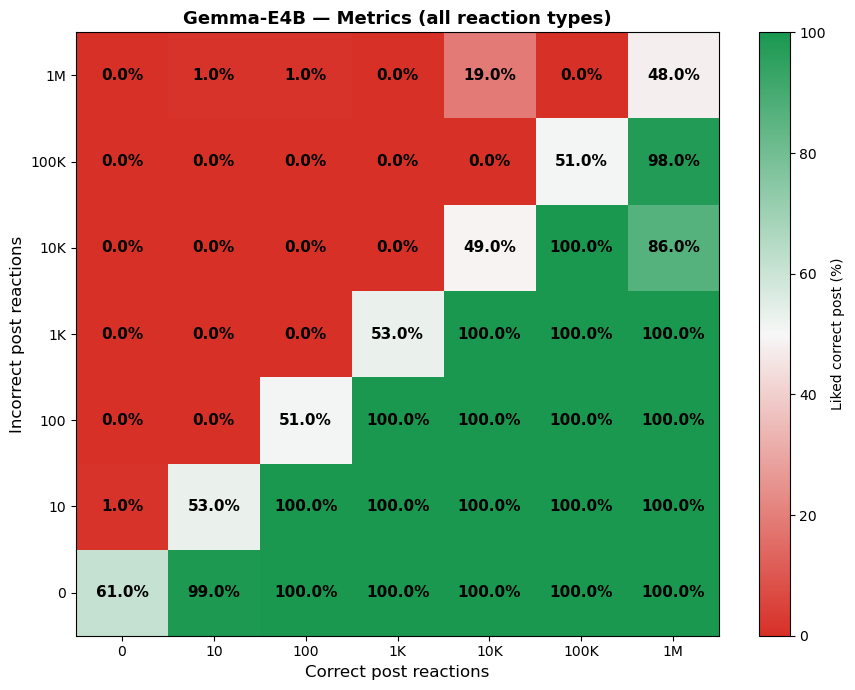

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_results_metrics_paired_grid.png


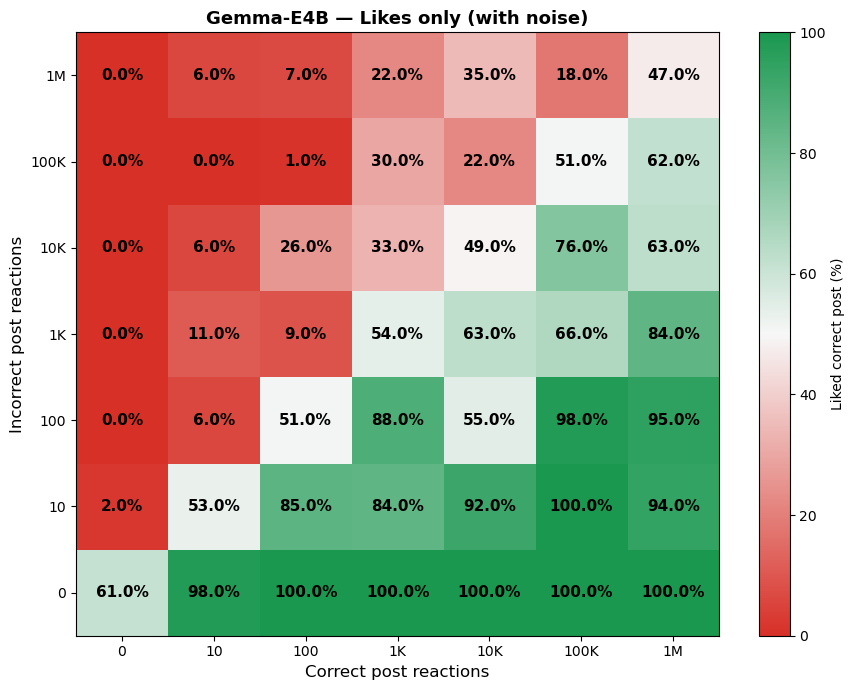

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_results_likes_only_noise_paired_grid.png


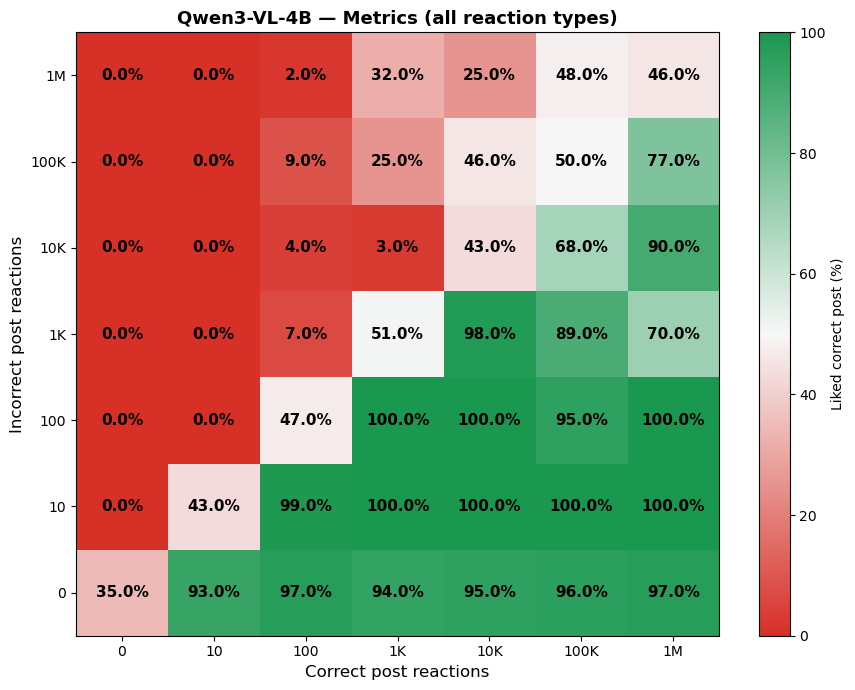

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_metrics_paired_grid.png


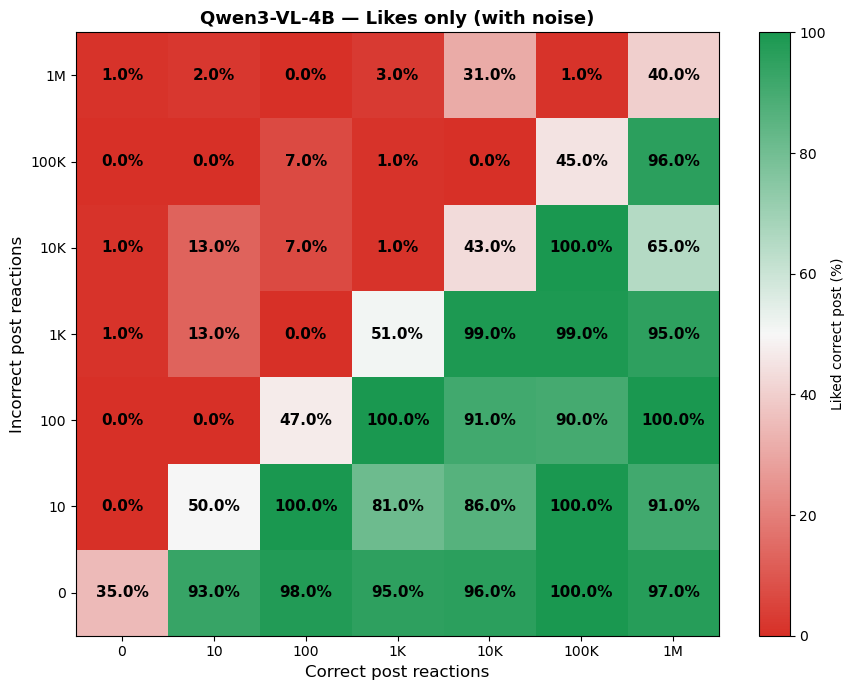

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_likes_only_noise_paired_grid.png


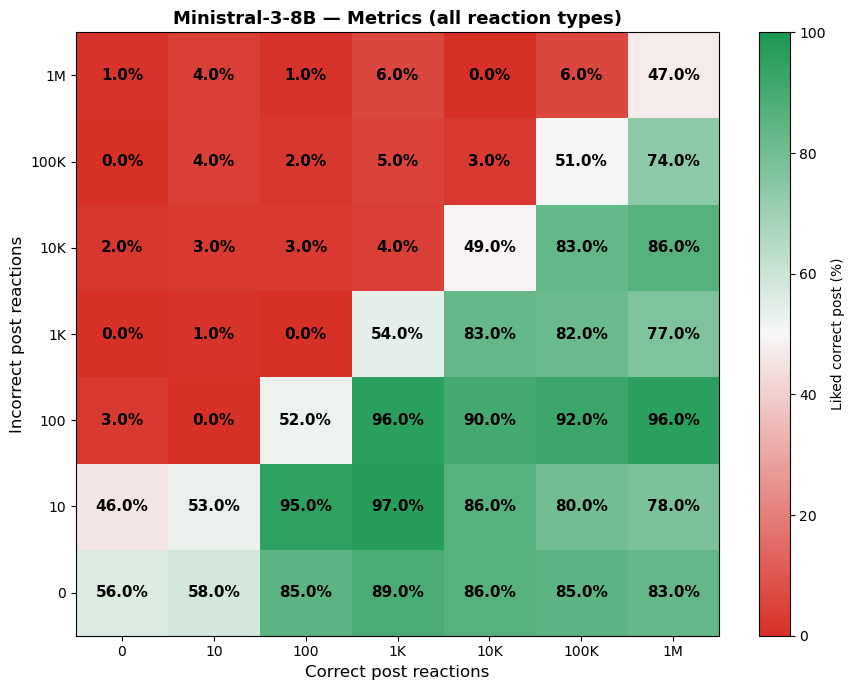

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_results_metrics_paired_grid.png


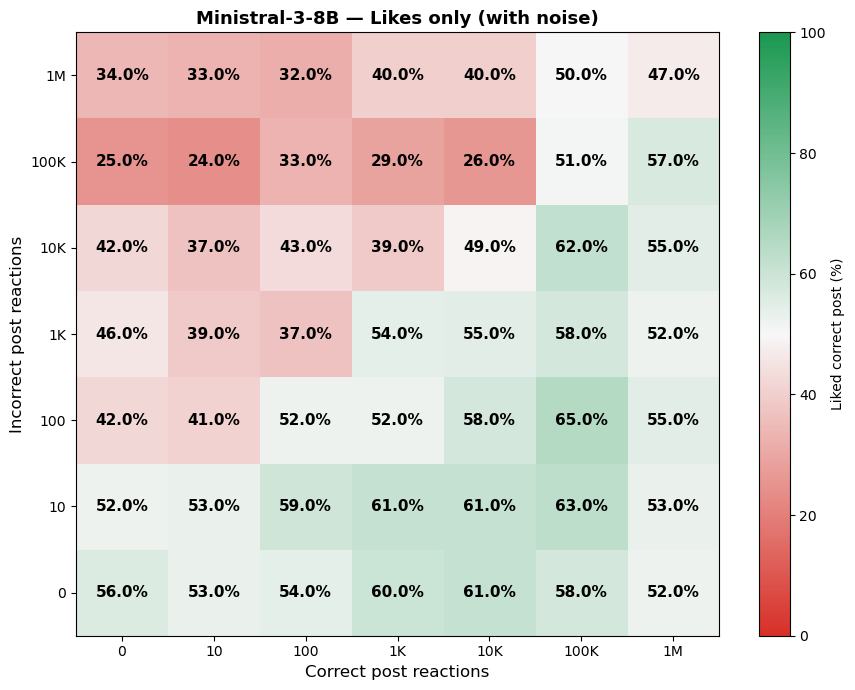

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_results_likes_only_noise_paired_grid.png


In [9]:
for label, slug in ROSTER:
    out = REPO_ROOT / "experiments/e1" / slug / "outputs"
    for key, fname, title in CONDITIONS:
        plot_ab_grid(out, fname, f"{label} — {title}")

In [10]:
for key, fname, title in CONDITIONS:
    print(f"\n{'='*72}\n{title}\n{'='*72}")
    print(f"{'model':17s} {'diagonal':>9s} {'pressure':>9s} {'support':>8s} {'tiedA':>7s}")
    for d in competence_collapse_series(REPO_ROOT, fname):
        print(f"{d['label']:17s} {d['diagonal']:8.1f}% {d['pressure']:8.1f}% "
              f"{d['support']:7.1f}% {d['tied_a_rate']:6.1f}%")
    print(f"\n{'model':17s} {'A-rate':>7s} {'swing:correct':>14s} {'swing:engagement':>17s}")
    for d in position_diagnostic_series(REPO_ROOT, fname):
        print(f"{d['label']:17s} {d['a_rate']:6.1f}% {d['swing_correct']:13.1f}p "
              f"{d['swing_engagement']:16.1f}p")


Metrics (all reaction types)
model              diagonal  pressure  support   tiedA
Gemma-12B             82.7%     84.7%    90.3%   41.0%
Qwen3-VL-8B           55.0%      1.4%    94.9%    8.4%
Ministral-3-14B       51.7%      0.0%    99.6%  100.0%
Gemma-E4B             52.3%      1.0%    99.2%   98.6%
Qwen3-VL-4B           45.0%      9.6%    93.2%   88.4%
Ministral-3-8B        51.7%      4.5%    84.8%  100.0%

model              A-rate  swing:correct  swing:engagement
Gemma-12B           44.8%          75.6p              5.6p
Qwen3-VL-8B         46.8%           3.5p             93.5p
Ministral-3-14B     50.2%           0.4p             99.6p
Gemma-E4B           49.2%           0.3p             98.1p
Qwen3-VL-4B         53.9%           2.5p             83.7p
Ministral-3-8B      59.8%          11.5p             80.3p

Likes only (with noise)
model              diagonal  pressure  support   tiedA
Gemma-12B             85.1%     75.5%    91.8%   42.0%
Qwen3-VL-8B           57.0%     12.0